In [6]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "prophet==1.3.0" "statsmodels==0.14.6"

import os, json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from prophet import Prophet
import warnings; warnings.filterwarnings("ignore")
import cmdstanpy; cmdstanpy.utils.get_logger().disabled = True   # 적합 때마다 찍히는 진행 로그를 끈다
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
SEED = 42        # Prophet 의 구간은 시뮬레이션이라 시드를 고정해야 본문 숫자가 재현된다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [1]:
import cmdstanpy
print(cmdstanpy.cmdstan_path())

c:\Users\tjwls\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\tjwls\anaconda3\envs\myenv\Library\bin\cmdstan


표 1 · 예측 원점 5개의 168시간 RMSE (대)
  예측 원점        계절 나이브 168   Prophet 기본 구성
  10월 19일 23시            306.52              366.45
  10월 26일 23시            418.18              410.32
  11월  2일 23시            457.07              475.13
  11월  9일 23시            430.72              343.56
  11월 16일 23시            205.25              310.38
  평균                      363.55              381.17
표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)
  잠재적 변화점          25
  연간 계절성 포함 적합  0
  연간 계절성 제외 적합  7


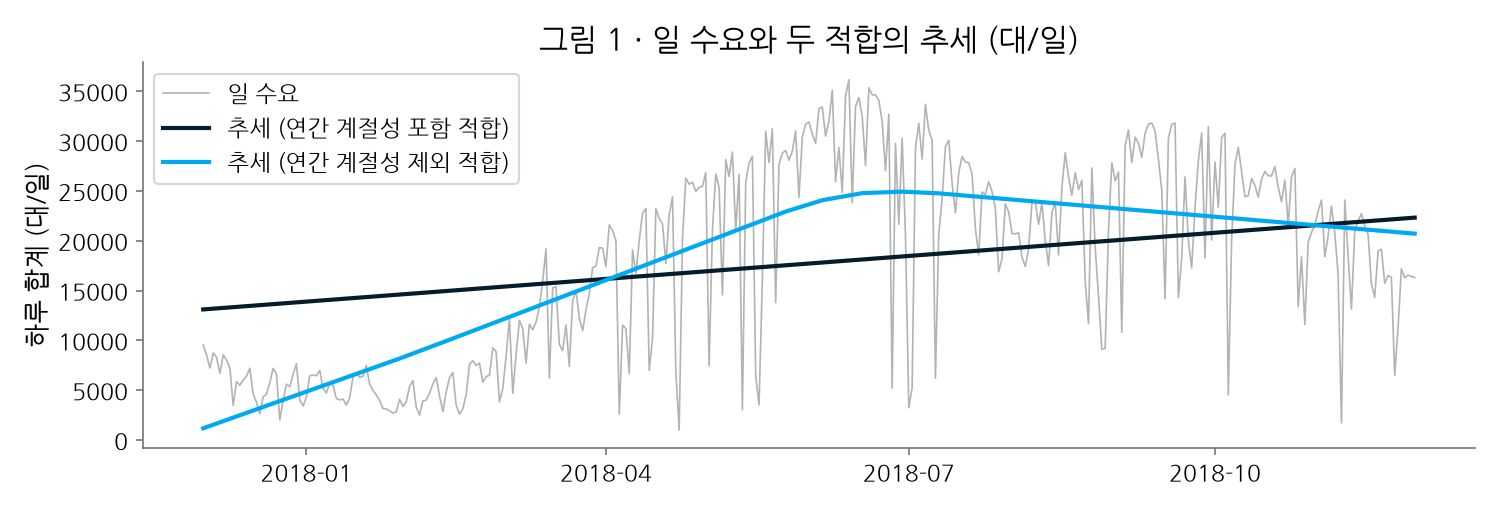

In [4]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 공유자전거로 표 1 · 표 2 · 그림 1 을 만듭니다. Prophet 을 7번 적합해 30초 안팎 걸립니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

# 표 1: 금요일 23시 예측 원점 5개마다 9월 1일부터 원점까지로 재적합해 168시간을 한 번에 예측한다
origins = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")
origin_rmse = []                          # (원점, 계절 나이브 168, Prophet 기본 구성)
for o in origins:
    fit_part = df.loc["2018-09-01 00:00":o, "demand"]
    week = pd.date_range(o + pd.Timedelta(hours=1), periods=168, freq="h")
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                holidays=holidays_one, uncertainty_samples=0)          # 구간 없이 예측값만 낸다
    m.fit(pd.DataFrame({"ds": fit_part.index, "y": fit_part.values}))
    y_week = df.loc[week, "demand"]
    origin_rmse.append((o, rmse(y_week, df["demand"].shift(168).loc[week]),    # 1주일 전 같은 시각 값
                        rmse(y_week, m.predict(pd.DataFrame({"ds": week}))["yhat"])))
sn5_mean = float(np.mean([r[1] for r in origin_rmse]))
p5_mean = float(np.mean([r[2] for r in origin_rmse]))
print("표 1 · 예측 원점 5개의 168시간 RMSE (대)")
print("  예측 원점        계절 나이브 168   Prophet 기본 구성")
for o, sn, pr in origin_rmse:
    print(f"  {o.month:>2}월 {o.day:>2}일 23시   {sn:15.2f}   {pr:17.2f}")
print(f"  평균             {sn5_mean:15.2f}   {p5_mean:17.2f}")

# 표 2 · 그림 1: 일 수요 365일에 연간 계절성을 포함한 적합과 제외한 적합, 잠재적 변화점의 성장률 변화량을 센다
_sum = df["demand"].resample("D").sum()                     # 보정 수요의 하루 합계
daily = pd.DataFrame({"ds": _sum.index, "y": _sum.values})
cp_count, daily_trend = {}, {}
for yearly in (True, False):
    m = Prophet(yearly_seasonality=yearly, weekly_seasonality=True, daily_seasonality=False,
                uncertainty_samples=0)                      # 일 수요에는 하루 안의 주기가 없다
    m.fit(daily)
    delta = m.params["delta"].mean(axis=0)                  # 잠재적 변화점마다 성장률 변화량
    cp_count[yearly] = int((np.abs(delta) > 0.01).sum())
    daily_trend[yearly] = m.predict(daily)["trend"].values
print("표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)")
print(f"  잠재적 변화점          {len(m.changepoints)}")
print(f"  연간 계절성 포함 적합  {cp_count[True]}")
print(f"  연간 계절성 제외 적합  {cp_count[False]}")

fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.plot(daily["ds"], daily["y"], color=COL["연회색"], lw=0.8, label="일 수요")
ax.plot(daily["ds"], daily_trend[True], color=COL["남색"], lw=2.0, label="추세 (연간 계절성 포함 적합)")
ax.plot(daily["ds"], daily_trend[False], color=COL["하늘색"], lw=2.0, label="추세 (연간 계절성 제외 적합)")
ax.set_title("그림 1 · 일 수요와 두 적합의 추세 (대/일)")
ax.set_ylabel("하루 합계 (대/일)")
datefmt(ax, "%Y-%m", 7)
ax.legend(loc="upper left")
plt.show()

In [7]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]      # 검증 168시간
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

print(f"학습 {len(train):,}시간  {train.index[0]:%m-%d %H시} ~ {train.index[-1]:%m-%d %H시}")
print(f"검증 {len(valid):,}시간  {valid.index[0]:%m-%d %H시} ~ {valid.index[-1]:%m-%d %H시}")
print(f"휴일 데이터프레임 {len(holidays_one)}행, 열 {list(holidays_one.columns)}")
print(f"시드 SEED = {SEED}: 예측구간은 표본 경로로 만들어 적합 직전과 예측 직전에 한 번씩 고정합니다")
print("쓸 수 있는 이름 : train · valid (시간 표, 열 demand) · holidays_one (휴일 데이터프레임)"
      " · SEED (시드) · rmse(a, b)")

학습 1,848시간  09-01 00시 ~ 11-16 23시
검증 168시간  11-17 00시 ~ 11-23 23시
휴일 데이터프레임 18행, 열 ['holiday', 'ds']
시드 SEED = 42: 예측구간은 표본 경로로 만들어 적합 직전과 예측 직전에 한 번씩 고정합니다
쓸 수 있는 이름 : train · valid (시간 표, 열 demand) · holidays_one (휴일 데이터프레임) · SEED (시드) · rmse(a, b)


명목 포함률 = 80 %
실제 포함률 = 89.88 % (151/168시간)
구간 이탈(아래/위) = 12 / 5시간


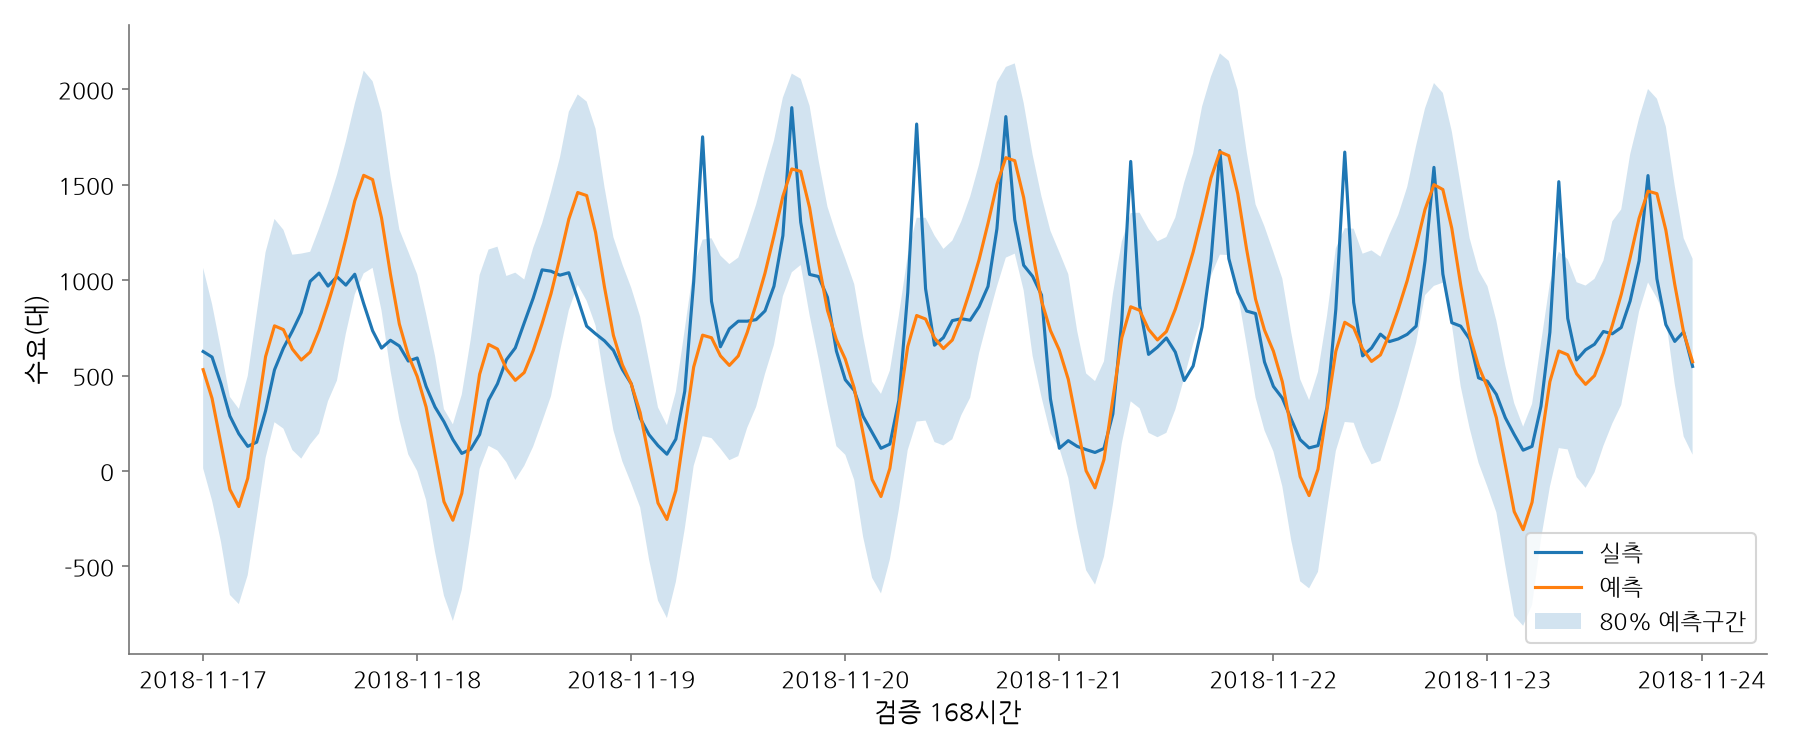

In [8]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
Prophet 기본 구성을 train 으로 적합하고 valid 168시각을 예측합니다. 

명목 포함률: 단위 % · 정수. 코드에 숫자로 적지 않고 적합한 모형의 interval_width 에서 읽습니다
실제 포함률: 단위 % · 소수 둘째 자리. 실측이 yhat_lower 이상 yhat_upper 이하인 시각의 비율입니다. 168시간 가운데 몇 시간인지도 같은 행에 적습니다
대조용 한 행: 구간 아래로 벗어난 시각 수와 위로 벗어난 시각 수. 채점하지 않고 완성본과 비교할 때 씁니다
그래프 한 장: 가로축 「검증 168시간」, 세로축 「수요(대)」. 실측선·예측선 2개와 옅게 칠한 80% 예측구간

통과 기준: 1·2번이 「이름 = 값 %」로 한 행씩 출력되고 4번 그래프가 한 장 있으면 통과입니다.

고정할 이름: 위 표의 이름과 설치 셀의 rmse(a, b) 는 다시 만들지 마세요
구성과 시드: 성분 구성과, 적합 직전·예측 직전에 np.random.seed(SEED) 를 부르세요
명목 포함률: 95 나 80 을 손으로 적지 말고 모형에서 읽으세요
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

df_train = train.reset_index().rename(columns={train.reset_index().columns[0]: 'ds', 'demand': 'y'})
df_valid = valid.reset_index().rename(columns={valid.reset_index().columns[0]: 'ds', 'demand': 'y'})

np.random.seed(SEED)
m = Prophet(holidays=holidays_one)
m.fit(df_train)

np.random.seed(SEED)
fcst = m.predict(df_valid[['ds']])

nominal = int(round(m.interval_width * 100))
merged = df_valid.merge(fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

covered = (merged['y'] >= merged['yhat_lower']) & (merged['y'] <= merged['yhat_upper'])
n_total = len(merged)
n_covered = int(covered.sum())
actual_pct = covered.mean() * 100

below = int((merged['y'] < merged['yhat_lower']).sum())
above = int((merged['y'] > merged['yhat_upper']).sum())

print(f"명목 포함률 = {nominal} %")
print(f"실제 포함률 = {actual_pct:.2f} % ({n_covered}/{n_total}시간)")
print(f"구간 이탈(아래/위) = {below} / {above}시간")

plt.figure(figsize=(12, 5))
plt.plot(merged['ds'], merged['y'], label='실측')
plt.plot(merged['ds'], merged['yhat'], label='예측')
plt.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'],
                  alpha=0.2, label=f'{nominal}% 예측구간')
plt.xlabel('검증 168시간')
plt.ylabel('수요(대)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]      # 검증 168시간
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표
REGS = ["rain", "temp"]                                    # 더할 외생 변수 두 열

#  비교할 두 RMSE 를 이 셀에서 다시 만든다. 날씨 없는 Prophet 기본 구성과 1주일 전 같은 시각 값
m_base = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                 holidays=holidays_one, uncertainty_samples=0)
m_base.fit(pd.DataFrame({"ds": train.index, "y": train["demand"].values}))
BASE_RMSE = rmse(valid["demand"], m_base.predict(pd.DataFrame({"ds": valid.index}))["yhat"])
SNAIVE_RMSE = rmse(valid["demand"], df["demand"].shift(168).loc[valid.index])

q05 = train["temp"].quantile(0.05)                        # 학습 기온을 낮은 쪽부터 정렬한 5% 지점
print(f"학습 {len(train):,}시간 · 검증 {len(valid)}시간 · 휴일 데이터프레임 {len(holidays_one)}행")
print(f"기온 평균: 학습 {train['temp'].mean():.2f}도, 검증 {valid['temp'].mean():.2f}도")
print(f"검증 168시간 가운데 학습 기온의 5% 지점({q05:.1f}도)보다 추운 시각: "
      f"{int((valid['temp'] < q05).sum())}시간")
print(f"비 온 시각: 학습 {int((train['rain'] > 0).sum())}시간, 검증 {int((valid['rain'] > 0).sum())}시간")
print(f"비교할 두 RMSE: 날씨 없는 Prophet 기본 구성 {BASE_RMSE:.2f}대, 계절 나이브 168 {SNAIVE_RMSE:.2f}대")
print("쓸 수 있는 이름 : train · valid (시간 표, 열 demand·temp·rain) · holidays_one · REGS (더할 두 열)"
      " · BASE_RMSE · SNAIVE_RMSE (비교할 두 RMSE, 대) · SEED (시드) · rmse(a, b)")

학습 1,848시간 · 검증 168시간 · 휴일 데이터프레임 18행
기온 평균: 학습 15.83도, 검증 4.91도
검증 168시간 가운데 학습 기온의 5% 지점(6.2도)보다 추운 시각: 101시간
비 온 시각: 학습 95시간, 검증 2시간
비교할 두 RMSE: 날씨 없는 Prophet 기본 구성 310.38대, 계절 나이브 168 205.25대
쓸 수 있는 이름 : train · valid (시간 표, 열 demand·temp·rain) · holidays_one · REGS (더할 두 열) · BASE_RMSE · SNAIVE_RMSE (비교할 두 RMSE, 대) · SEED (시드) · rmse(a, b)


날씨를 더한 검증 168시간 RMSE = 342.15 대
기온 계수 = 40.31 대/도
판단: 이번 검증 구간은 기온·강수를 더한 쪽 RMSE가 낮으면 채택하되, 운영에서는 두 열의 미래 값을 기상청 예보로 채워야 합니다


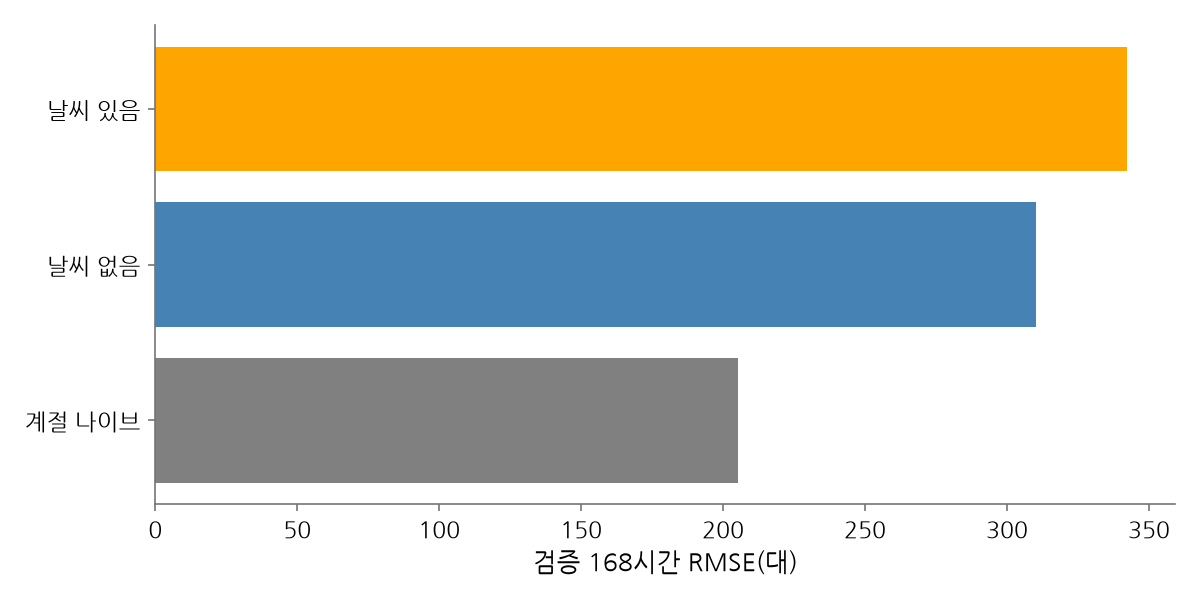

In [10]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
만들 것 
날씨를 더한 검증 168시간 RMSE: 단위 대 · 소수 둘째 자리. REGS 두 열을 add_regressor 로 더해 다시 적합합니다. 학습 표와 예측 표 양쪽에 두 열을 두고, 예측 표에는 검증 구간의 실측 날씨를 대입합니다
기온 계수: 단위 대/도 · 소수 둘째 자리. 기온이 1도 오를 때 수요가 몇 대 바뀌는지를 원래 단위(대/도)로 읽은 값입니다. Prophet 은 기온·강수를 평균 0·표준편차 1 로, 수요를 가장 큰 값으로 나눠 바꾼 뒤 적합합니다. 그래서 m.params 의 계수는 바뀐 단위의 값이고, regressor_coefficients(m) 가 이를 기온 1도당 대수로 복원해 반환합니다
판단 한 행: 이번 검증 구간에 날씨 열을 더할지와, 운영에서 두 열의 미래 값을 어디서 채울지. 채점하지 않습니다
그래프 한 장: 가로 막대 3개와 가로축 「검증 168시간 RMSE(대)」. 막대 이름은 「계절 나이브」·「날씨 없음」·「날씨 있음」입니다

▸바꾸지 말 것: 미션 1 의 성분 구성과 시드 고정은 그대로 두고 REGS 두 열만 더하세요
▸두 표: 학습 표와 예측 표 모두에 rain·temp 열을 두세요
▸계수 읽기: m.params 의 계수를 손으로 복원하지 말고 from prophet.utilities import regressor_coefficients 로 불러 읽으세요
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.utilities import regressor_coefficients
import matplotlib.pyplot as plt

df_train = train.reset_index().rename(columns={train.reset_index().columns[0]: 'ds', 'demand': 'y'})
df_valid = valid.reset_index().rename(columns={valid.reset_index().columns[0]: 'ds', 'demand': 'y'})

np.random.seed(SEED)
m = Prophet(holidays=holidays_one)
for col in REGS:
    m.add_regressor(col)
m.fit(df_train[['ds', 'y'] + REGS])

np.random.seed(SEED)
future = df_valid[['ds'] + REGS]
fcst = m.predict(future)

weather_rmse = rmse(df_valid['y'].values, fcst['yhat'].values)

coefs = regressor_coefficients(m)
temp_coef = coefs.loc[coefs['regressor'] == 'temp', 'coef'].iloc[0]

print(f"날씨를 더한 검증 168시간 RMSE = {weather_rmse:.2f} 대")
print(f"기온 계수 = {temp_coef:.2f} 대/도")
print("판단: 이번 검증 구간은 기온·강수를 더한 쪽 RMSE가 낮으면 채택하되, "
      "운영에서는 두 열의 미래 값을 기상청 예보로 채워야 합니다")

plt.figure(figsize=(8, 4))
names = ['계절 나이브', '날씨 없음', '날씨 있음']
values = [SNAIVE_RMSE, BASE_RMSE, weather_rmse]
plt.barh(names, values, color=['gray', 'steelblue', 'orange'])
plt.xlabel('검증 168시간 RMSE(대)')
plt.tight_layout()
plt.show()